### Домашка

1. Скачать [датасет по ссылке](https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv) (просто запустить строку ниже)

In [1]:
!wget https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv

--2025-11-03 15:50:24--  https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102826 (100K) [text/plain]
Saving to: ‘test.csv’

test.csv            100%[===================>] 100.42K  --.-KB/s    in 0.02s   

2025-11-03 15:50:24 (4.41 MB/s) - ‘test.csv’ saved [102826/102826]



2. Открыть csv и сохранить текст в переменную (макс. балл == 1)

In [3]:
import pandas as pd

df = pd.read_csv('test.csv', encoding='utf-8')
df.head()

,text,label,source
0,Trying to have a conversation with my dad abou...,negative,sem_eval_2017
1,#latestnews 4 #newmexico #politics + #nativeam...,neutral,sem_eval_2017
2,@user You are a stand up guy and a Gentleman V...,positive,sem_eval_2017
3,@user @user @user Looks like Flynn isn't too p...,negative,sem_eval_2017
4,perfect pussy clips #vanessa hudgens zac efron...,neutral,sem_eval_2017


3. Извлечь столбец с текстами (макс. балл == 1)

In [4]:
texts = df.text
texts.head()

,text
0,Trying to have a conversation with my dad abou...
1,#latestnews 4 #newmexico #politics + #nativeam...
2,@user You are a stand up guy and a Gentleman V...
3,@user @user @user Looks like Flynn isn't too p...
4,perfect pussy clips #vanessa hudgens zac efron...


4. Построить Bag-of-Words (макс. балл == 3)

In [5]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.6 MB/s eta 0:00:00


In [6]:
import gensim
from gensim import corpora
from gensim.models import TfidfModel
from gensim.parsing.preprocessing import remove_stopwords
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [15]:
# Приводим тексты к нижнему регистру
texts_lower = texts.str.lower()
# Удаляем знаки препинания (не только: хештеги и остальные символы тоже удалены)
texts_clean = texts_lower.str.replace(r'[^(\w|\s)]', '', regex=True)
# Строим словарь
texts_dictionary = texts_clean.str.split()
dictionary = corpora.Dictionary(texts_dictionary)
# Преобразуем документы в BoW векторы
bow_corpus = [dictionary.doc2bow(doc) for doc in texts_dictionary]
for i, doc_vec in enumerate(bow_corpus[:10], 1):
    print(f"Документ {i}: {doc_vec}")

Документ 1: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1)]
Документ 2: [(18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1)]
Документ 3: [(0, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1)]
Документ 4: [(17, 1), (38, 4), (40, 1), (41, 2), (42, 1), (43, 2), (44, 1), (45, 1), (46, 1), (47, 1), (48, 2), (49, 1), (50, 2)]
Документ 5: [(51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1)]
Документ 6: [(8, 2), (10, 1), (14, 1), (30, 1), (46, 1), (48, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1)]
Документ 7: [(1, 1), (6, 1), (8, 1), (12, 1), (38, 1), (40, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1

user - 570
the - 387
to - 268
a - 227
of - 199
is - 186
for - 176
in - 165
and - 163
i - 135
on - 118
you - 92
this - 80
it - 79
that - 79
with - 71
are - 65
trump - 62
be - 60
not - 58


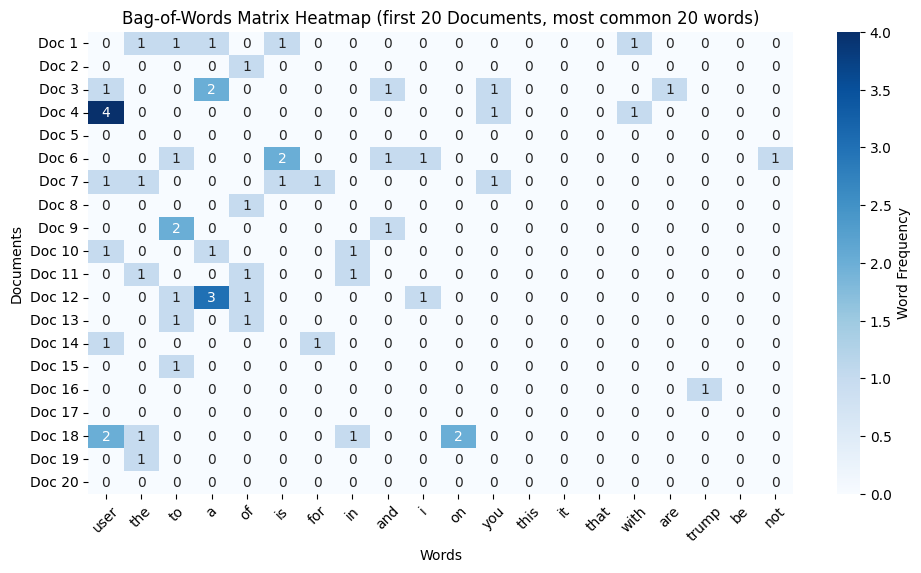

In [16]:
# Создаем таблицу частот слов
def bow_to_dense(bow_corpus, dictionary):
    dense_vectors = []
    for doc in bow_corpus:
        dense_vec = [0] * len(dictionary)
        for idx, freq in doc:
            dense_vec[idx] = freq
        dense_vectors.append(dense_vec)
    return dense_vectors

dense_vectors = bow_to_dense(bow_corpus, dictionary)

# Ищем индексы 20 самых частых слов
most_common_ind = []
for i in sorted(dictionary.most_common(20), key=lambda item: item[1], reverse=True):
    most_common_ind.append(dictionary.token2id[i[0]])

# Для отрисовки берем первые 20 документов и 20 самых частовстречаемых слов
matrix = np.array(dense_vectors)[:20, most_common_ind]
words = [i[0] for i in dictionary.most_common(20)]
doc_names = [f"Doc {i+1}" for i in range(len(texts_dictionary))][:20]

# Строим heatmap матрицы BoW
plt.figure(figsize=(25, 6))

plt.subplot(1, 2, 1)
sns.heatmap(matrix,
            annot=True,
            fmt='d',
            xticklabels=words,
            yticklabels=doc_names,
            cmap='Blues',
            cbar_kws={'label': 'Word Frequency'})
plt.title('Bag-of-Words Matrix Heatmap (first 20 Documents, most common 20 words)')
plt.xticks(rotation=45)
plt.ylabel('Documents')
plt.xlabel('Words')
# Печатаем самые частые слова в корпусе с частотой
for i in dictionary.most_common(20):
    print(f'{i[0]} - {i[1]}')

5. Построить TF-IDF (макс. балл == 5)

In [17]:
# Используем TfidfModel из gensim
tfidf_model = TfidfModel(bow_corpus)
# Получаем TF-IDF векторы для каждого документа
tfidf_corpus = tfidf_model[bow_corpus]

for i, doc_vec in enumerate(tfidf_corpus[:10], 1):
    print(f"Документ {i}: {[(dictionary[idx], round(score, 3)) for idx, score in doc_vec]}")

Документ 1: [('a', np.float64(0.078)), ('about', np.float64(0.163)), ('caveman', np.float64(0.35)), ('conversation', np.float64(0.35)), ('dad', np.float64(0.314)), ('ever', np.float64(0.257)), ('have', np.float64(0.149)), ('infuriating', np.float64(0.35)), ('is', np.float64(0.087)), ('most', np.float64(0.21)), ('my', np.float64(0.15)), ('pointless', np.float64(0.35)), ('the', np.float64(0.056)), ('thing', np.float64(0.236)), ('to', np.float64(0.069)), ('trying', np.float64(0.293)), ('vegetarianism', np.float64(0.226)), ('with', np.float64(0.132))]
Документ 2: [('4', np.float64(0.238)), ('altright', np.float64(0.281)), ('at', np.float64(0.162)), ('israel', np.float64(0.234)), ('latestnews', np.float64(0.369)), ('nativeamerican', np.float64(0.369)), ('newmexico', np.float64(0.369)), ('of', np.float64(0.086)), ('palestine', np.float64(0.256)), ('politics', np.float64(0.309)), ('protesting', np.float64(0.331)), ('rise', np.float64(0.309))]
Документ 3: [('a', np.float64(0.192)), ('and', np.

In [18]:
def analyze_tfidf_components(bow_corpus, dictionary):
    # Шаг 1: Создаем матрицу TF (term frequency)
    tf_matrix = np.zeros((len(bow_corpus), len(dictionary)))
    for doc_idx, doc in enumerate(bow_corpus):
        for word_idx, freq in doc:
            tf_matrix[doc_idx, word_idx] = freq

    # Шаг 2: Вычисляем DF (document frequency)
    df_vector = np.sum(tf_matrix > 0, axis=0)  # Количество документов с каждым словом

    # Шаг 3: Вычисляем IDF (inverse document frequency)
    N = len(bow_corpus)  # общее количество документов
    idf_vector = np.log(N / (df_vector + 1)) + 1

    # Шаг 4: Вычисляем TF-IDF вручную
    tfidf_manual = tf_matrix * idf_vector

    return tf_matrix, df_vector, idf_vector, tfidf_manual

In [19]:
# Для каждого слова вычисляем:
#   * TF (term frequency) в каждом документе
#   * DF (document frequency) во всем корпусе
#   * IDF (inverse document frequency)
#   * значение TF-IDF
tfidf = analyze_tfidf_components(bow_corpus, dictionary)
# Создаем датафрейм для первого документа
tfidf_first = pd.DataFrame({'TF': tfidf[0][0],
                            'DF': tfidf[1],
                            'IDF': tfidf[2],
                            'TF-IDF': tfidf[3][0]})
# Изменяем индексы на слова
tfidf_first.rename(index=dictionary.id2token, inplace=True)
# Сохраняем в csv
tfidf_first.to_csv('tfidf_first.csv', index=True, encoding='utf-8')
tfidf_first.head()

,TF,DF,IDF,TF-IDF
a,1.0,191,2.510998,2.510998
about,1.0,37,4.130907,4.130907
caveman,1.0,1,7.075346,7.075346
conversation,1.0,1,7.075346,7.075346
dad,1.0,2,6.669881,6.669881


##### **Как вычислить компоненты вручную**

```python
def analyze_tfidf_components(bow_corpus, dictionary):
    # Шаг 1: Создаем матрицу TF (term frequency)
    tf_matrix = np.zeros((len(bow_corpus), len(dictionary)))
    for doc_idx, doc in enumerate(bow_corpus):
        for word_idx, freq in doc:
            tf_matrix[doc_idx, word_idx] = freq
    
    # Шаг 2: Вычисляем DF (document frequency)
    df_vector = np.sum(tf_matrix > 0, axis=0)  # Количество документов с каждым словом
    
    # Шаг 3: Вычисляем IDF (inverse document frequency)
    N = len(bow_corpus)  # общее количество документов
    idf_vector = np.log(N / (df_vector + 1)) + 1
    
    # Шаг 4: Вычисляем TF-IDF вручную
    tfidf_manual = tf_matrix * idf_vector
    
    return tf_matrix, df_vector, idf_vector, tfidf_manual
```

6. Произвести сравните

*Эта часть не оценивается, но будет давать доп. баллы на экзамене для тех, кто выполнит её*

In [21]:
def compare_bow_tfidf(words, bow_dense, tfidf_dense, dictionary):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for i, word in enumerate(words):
        row, col = i // 2, i % 2
        word_id = dictionary.token2id[word]

        # Веса для этого слова во всех документах
        bow_weights = [doc[word_id] for doc in bow_dense]
        tfidf_weights = [doc[word_id] for doc in tfidf_dense]

        x = range(len(bow_dense))
        axes[row, col].bar(x, bow_weights, alpha=0.7, label='BoW', width=0.4)
        axes[row, col].bar([p + 0.4 for p in x], tfidf_weights, alpha=0.7, label='TF-IDF', width=0.4)
        axes[row, col].set_title(f'Сравнение весов: "{word}"')
        axes[row, col].legend()
        axes[row, col].set_xticks([p + 0.2 for p in x])
        axes[row, col].set_xticklabels([f'{i+1}' for i in x])

    plt.tight_layout()
    plt.show()

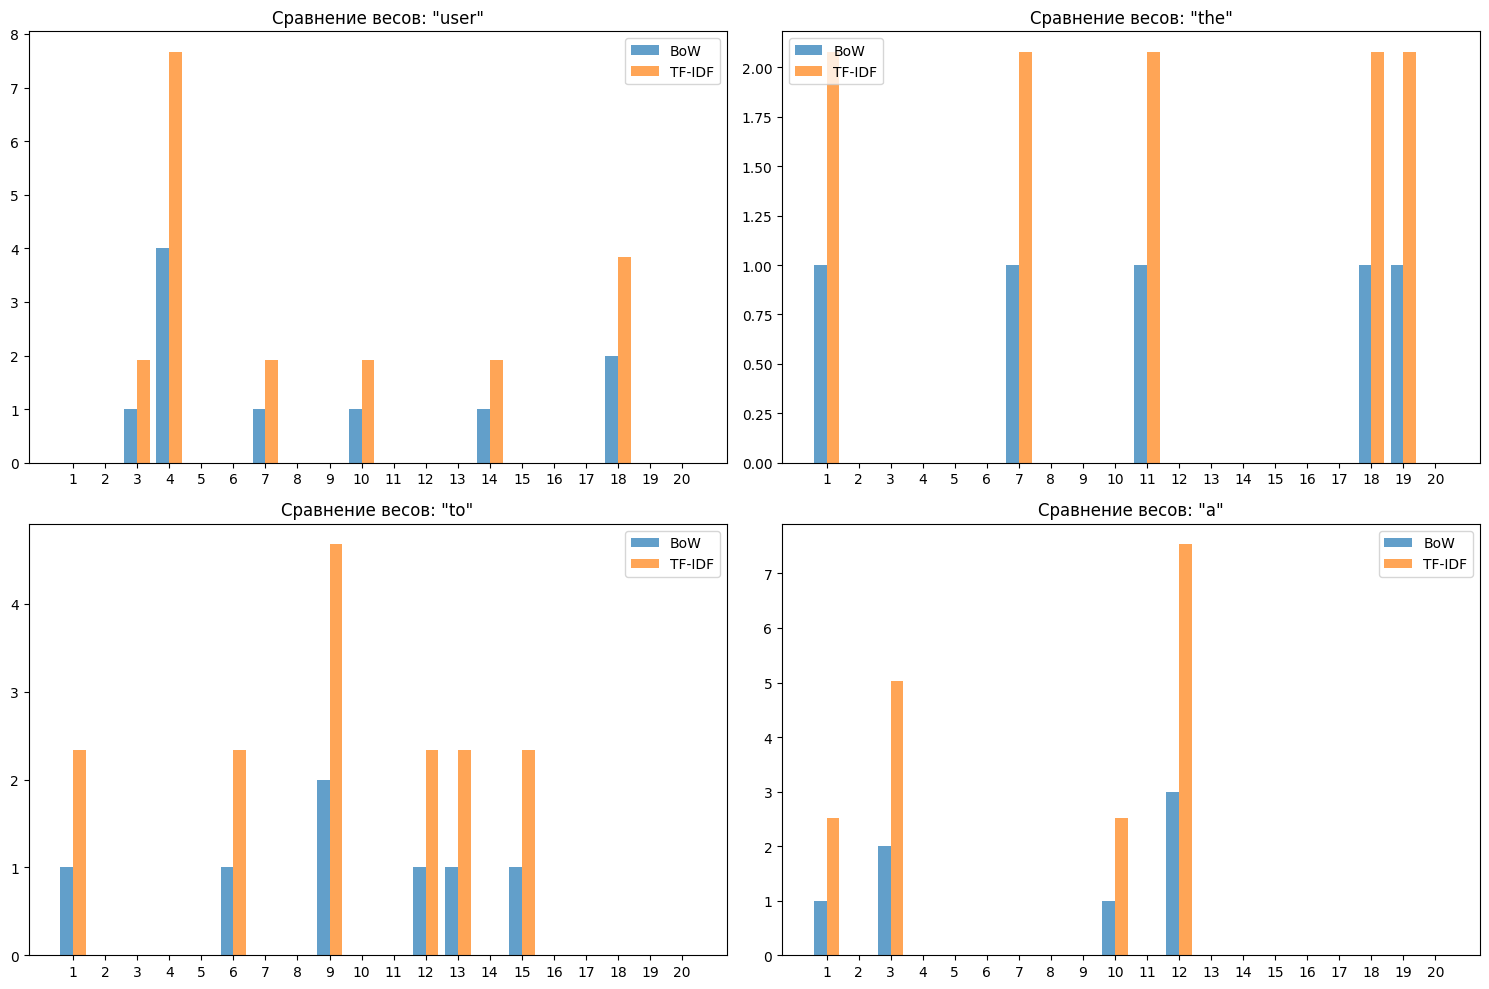

In [22]:
# Первые 4 самых частых слова в 20 документах
compare_bow_tfidf(['user', 'the', 'to', 'a'], dense_vectors[:20], tfidf[3][:20], dictionary)

##### **Как построить сравнительный график**
```python
def compare_bow_tfidf(words, bow_dense, tfidf_dense, dictionary):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    for i, word in enumerate(words):
        row, col = i // 2, i % 2
        word_id = dictionary.token2id[word]
        
        # Веса для этого слова во всех документах
        bow_weights = [doc[word_id] for doc in bow_dense]
        tfidf_weights = [doc[word_id] for doc in tfidf_dense]
        
        x = range(len(bow_dense))
        axes[row, col].bar(x, bow_weights, alpha=0.7, label='BoW', width=0.4)
        axes[row, col].bar([p + 0.4 for p in x], tfidf_weights, alpha=0.7, label='TF-IDF', width=0.4)
        axes[row, col].set_title(f'Сравнение весов: "{word}"')
        axes[row, col].legend()
        axes[row, col].set_xticks([p + 0.2 for p in x])
        axes[row, col].set_xticklabels([f'Док {i+1}' for i in x])
    
    plt.tight_layout()
    plt.show()
```